In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tqdm import tqdm
import itertools
import re

In [18]:
base_path = "/n/netscratch/kempner_sham_lab/Everyone/ameterez/synthetics_recursion"
all_jobs = os.listdir(base_path)
print(len(all_jobs))
sigma2 = 0.0001

21168


In [19]:
def topk_params_at_step(df: pd.DataFrame, step_value: int, k: int = 10) -> pd.DataFrame:
    # Filter to that step
    d = df[df["step"] == step_value].copy()

    if d.empty:
        raise ValueError(f"No rows found for step={step_value}")

    # If you have multiple rows per (offset, ema, eta) at the same step (e.g. multiple seeds),
    # aggregate; using mean is typical, but you can swap to min if you prefer.
    agg = (
        d.groupby(PARAMS, as_index=False)["total_risk"]
         .mean()
         .sort_values("total_risk", ascending=True)
         .head(k)
    )
    return agg
def parse_job_params(job: str) -> dict:
    """
    Parse params from filenames like:
    alg_sqrt_alpha_1.1_betaMul_1_eta_0.1_sigma2_0.0001_seed_0_d_200000_a_12800_ema_16_N_50000.csv
    Returns dict of key -> number (int or float).
    """
    stem = os.path.splitext(os.path.basename(job))[0]

    # Remove leading algorithm prefix (keep it if you want)
    # e.g. "alg_sqrt_" prefix
    # if stem.startswith("alg_sqrt_"):
    #     stem = stem[len("alg_sqrt_"):]
    # elif stem.startswith("alg_sqrt"):
    #     stem = stem[len("alg_sqrt"):].lstrip("_")

    toks = stem.split("_")

    # Expect alternating key/value pairs: key0, val0, key1, val1, ...
    params = {}
    i = 0
    while i + 1 < len(toks):
        k, v = toks[i], toks[i + 1]

        # value parsing: int if it looks like int, else float
        # Handles scientific notation too.
        if re.fullmatch(r"[+-]?\d+", v):
            params[k] = int(v)
        elif re.fullmatch(r"[+-]?(\d+(\.\d*)?|\.\d+)([eE][+-]?\d+)?", v):
            params[k] = float(v)
        else:
            # If some trailing token isn't numeric (rare), just keep string
            params[k] = v

        i += 2

    return params

In [20]:
# alg_sqrt_alpha_1.1_betaMul_1_eta_0.1_sigma2_0.0001_seed_0_d_200000_a_12800_ema_16_N_50000.csv
PARAMS = ["a", "ema", "eta"]
filtered_jobs = [x for x in all_jobs if f"alg_sqrt" in x]
print(len(filtered_jobs))
dfs = []
for job in tqdm(filtered_jobs):
    fname = os.path.join(base_path, job)
    params = parse_job_params(job)

    df_run = pd.read_csv(fname)

    # Add params as columns in one shot (broadcasts scalars)
    df_run = df_run.assign(**params)

    dfs.append(df_run)

df = pd.concat(dfs, ignore_index=True)

alphas = [1.1, 1.5, 1.9]
beta_muls = [1.0, 2.0]
runs = itertools.product(alphas, beta_muls)

sqrt_dfs = []
for alpha, beta_mul in runs:
    print((alpha, beta_mul))
    df_filtered = df[(df["sigma2"] == sigma2) & (df["alpha"] == alpha) & (df["betaMul"] == beta_mul)].copy()
    s1000 = (
        df_filtered[df_filtered["step"] == 1000]
        .groupby(PARAMS)["total_risk"]
        .mean()
        .rename("r1000")
    )
    s50k = (
        df_filtered[df_filtered["step"] == 50000]
        .groupby(PARAMS)["total_risk"]
        .mean()
        .rename("r50000")
    )
    both = s1000.to_frame().join(s50k, how="inner").reset_index()
    if both.empty:
        print("EMPTY!!!!!!")

    # (2) ranks within this (alpha, beta_mul, sigma2) slice
    both["rank1000"] = both["r1000"].rank(method="min", ascending=True)
    both["rank50k"] = both["r50000"].rank(method="min", ascending=True)

    # (3) keep your "top-at-end then also good at start" logic, but rank-based:
    #     take top-K by final rank, then pick best by early rank (tie-break by final/early risks)
    K_END = 5
    cand = both.nsmallest(K_END, "r50000")                 # best-at-end set
    pick = cand.sort_values(["r1000", "r50000"]).iloc[0]   # tie-break by early

    offset = pick["a"]
    ema = pick["ema"]
    eta = pick["eta"]
    print(offset, ema, eta)
    # -----------------------------------------------

    df_best = df_filtered[
        (df_filtered["a"] == offset) &
        (df_filtered["ema"] == ema) &
        (df_filtered["eta"] == eta)
    ].copy()

    sqrt_dfs.append(df_best)

sqrt_df = pd.concat(sqrt_dfs, ignore_index=True)

5880


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5880/5880 [00:09<00:00, 591.89it/s]


(1.1, 1.0)
25600.0 2.0 0.25
(1.1, 2.0)
12800.0 8.0 1.0
(1.5, 1.0)
25600.0 2.0 0.1
(1.5, 2.0)
25600.0 8.0 0.5
(1.9, 1.0)
25600.0 1.0 0.1
(1.9, 2.0)
25600.0 4.0 0.5


In [21]:
# alg_constant_a_1_alpha_1.1_betaMul_1_eta_0.1_sigma2_0.001_seed_0_ema_1.csv
PARAMS = ["ema", "eta"]

filtered_jobs = [x for x in all_jobs if "alg_constant" in x]
print(len(filtered_jobs))

dfs = []
for job in tqdm(filtered_jobs):
    fname = os.path.join(base_path, job)
    params = parse_job_params(job)   # <- new parsing

    df_run = pd.read_csv(fname)

    # Add params as columns in one shot (broadcasts scalars)
    df_run = df_run.assign(**params)

    dfs.append(df_run)

df = pd.concat(dfs, ignore_index=True)

alphas = [1.1, 1.5, 1.9]
beta_muls = [1.0, 2.0]
runs = itertools.product(alphas, beta_muls)

constant_dfs = []
for alpha, beta_mul in runs:
    print((alpha, beta_mul))
    df_filtered = df[
        (df["sigma2"] == sigma2) &
        (df["alpha"] == alpha) &
        (df["betaMul"] == beta_mul)
    ].copy()

    # --- rank-based selection over PARAMS=["ema","eta"] ---
    s1000 = (
        df_filtered[df_filtered["step"] == 1000]
        .groupby(PARAMS)["total_risk"]
        .mean()
        .rename("r1000")
    )
    s50k = (
        df_filtered[df_filtered["step"] == 50000]
        .groupby(PARAMS)["total_risk"]
        .mean()
        .rename("r50000")
    )

    both = s1000.to_frame().join(s50k, how="inner").reset_index()
    if both.empty:
        print("EMPTY!!!!!!!")
        continue

    both["rank1000"] = both["r1000"].rank(method="min", ascending=True)
    both["rank50k"] = both["r50000"].rank(method="min", ascending=True)

    # take top-K by final, then best among those by early (tie-breakers included)
    K_END = 5
    cand = both.nsmallest(K_END, "r50000")               # best-at-end set
    pick = cand.sort_values(["r1000", "r50000"]).iloc[0] # tie-break by early

    ema = pick["ema"]
    eta = pick["eta"]
    print(ema, eta)

    df_best = df_filtered[
        (df_filtered["ema"] == ema) &
        (df_filtered["eta"] == eta)
    ].copy()

    constant_dfs.append(df_best)

constant_df = pd.concat(constant_dfs, ignore_index=True)


5880


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5880/5880 [00:09<00:00, 591.16it/s]


(1.1, 1.0)
2.0 0.25
(1.1, 2.0)
2.0 1.0
(1.5, 1.0)
2.0 0.1
(1.5, 2.0)
8.0 0.5
(1.9, 1.0)
1.0 0.1
(1.9, 2.0)
4.0 0.5


In [22]:
# alg_wsd_a_1_alpha_1.1_betaMul_1_eta_0.1_sigma2_0.001_seed_0_p_0.3_T_1000.csv
PARAMS = ["eta", "p"]

filtered_jobs = [x for x in all_jobs if "alg_wsd" in x]
print(len(filtered_jobs))

dfs = []
for job in tqdm(filtered_jobs):
    fname = os.path.join(base_path, job)
    params = parse_job_params(job)  # gives keys like alpha, betaMul, eta, sigma2, p, T, seed, ...

    df_run = pd.read_csv(fname).assign(**params)
    dfs.append(df_run)

df = pd.concat(dfs, ignore_index=True)

alphas = [1.1, 1.5, 1.9]
beta_muls = [1.0, 2.0]
runs = itertools.product(alphas, beta_muls)

wsd_rows = []
for alpha, beta_mul in runs:
    print((alpha, beta_mul))
    df_filtered = df[
        (df["sigma2"] == sigma2) &
        (df["alpha"] == alpha) &
        (df["betaMul"] == beta_mul)
    ].copy()

    # pick (eta, p) by comparing endpoints at T==1000 and T==50000
    s1000 = (
        df_filtered[(df_filtered["T"] == 1000) & (df_filtered["step"] == 1000)]
        .groupby(PARAMS)["total_risk"]
        .mean()
        .rename("r1000")
    )
    s50k = (
        df_filtered[(df_filtered["T"] == 50000) & (df_filtered["step"] == 50000)]
        .groupby(PARAMS)["total_risk"]
        .mean()
        .rename("r50000")
    )

    both = s1000.to_frame().join(s50k, how="inner").reset_index()
    if both.empty:
        print("EMPTY!!!!!!!")
        continue

    both["rank1000"] = both["r1000"].rank(method="min", ascending=True)
    both["rank50k"] = both["r50000"].rank(method="min", ascending=True)

    K_END = 5
    cand = both.nsmallest(K_END, "r50000")               # best-at-end set
    pick = cand.sort_values(["r1000", "r50000"]).iloc[0] # tie-break by early

    eta = pick["eta"]
    p = pick["p"]
    print(eta, p)

    # collect one summary row per T (taking the last row of that run)
    for T in [1000, 2000, 3000, 5000, 8000, 10000, 50000]:
        sub = df_filtered[
            (df_filtered["p"] == p) &
            (df_filtered["eta"] == eta) &
            (df_filtered["T"] == T)
        ]
        if sub.empty:
            continue
        wsd_rows.append(sub.iloc[-1])

wsd_df = pd.DataFrame(wsd_rows)

9408


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9408/9408 [00:15<00:00, 612.62it/s]


(1.1, 1.0)
0.25 0.3
(1.1, 2.0)
0.5 0.8
(1.5, 1.0)
0.1 0.3
(1.5, 2.0)
0.5 0.5
(1.9, 1.0)
0.1 0.3
(1.9, 2.0)
0.5 0.3


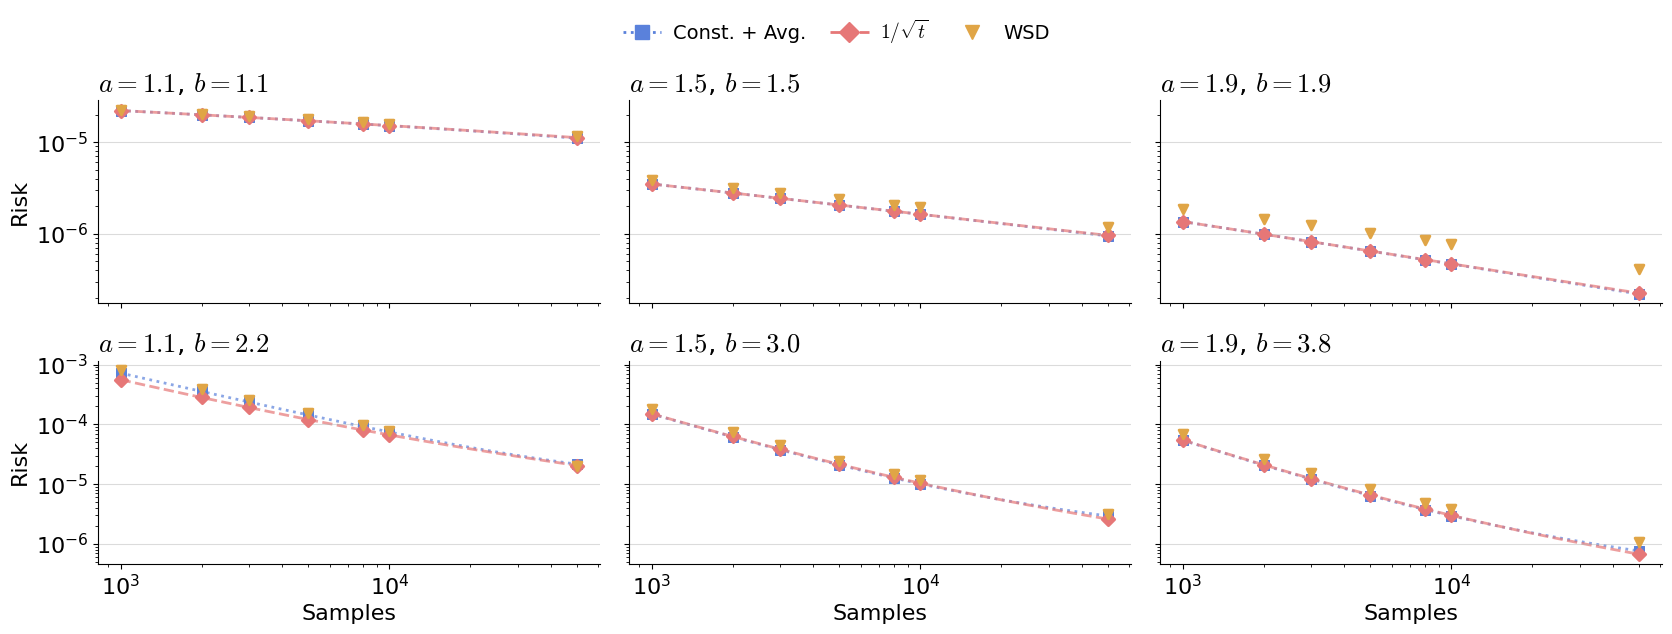

In [23]:
import itertools
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# -----------------------------
# Style Configuration (match your example)
# -----------------------------
mpl.rcParams.update({
    "text.usetex": False,
    "mathtext.fontset": "cm",
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 16,
})

# Colors
constant_trace_color = "#5a81db"
sqrt_trace_color = "#e67777"
wsd_color = "#e0a546"

# Line styles
linestyle_map = {"constant": ":", "sqrt": "--"}

# Marker styles
marker_map = {"constant": "s", "sqrt": "D", "wsd": "v"}

# Sizes
LINEWIDTH = 2
LINE_ALPHA = 0.7
MARKER_S = 40
MARKER_LW = 2

# -----------------------------
# Prepare data
# -----------------------------
sqrt_df = sqrt_df.copy()
constant_df = constant_df.copy()
wsd_df = wsd_df.copy()

sqrt_df["scheduler"] = "sqrt"
constant_df["scheduler"] = "constant"
wsd_df["scheduler"] = "wsd"

full_df = pd.concat([sqrt_df, constant_df, wsd_df], ignore_index=True)
full_df = full_df[full_df["step"] >= 1000].copy()
full_df["step"] = pd.to_numeric(full_df["step"])
full_df["total_risk"] = pd.to_numeric(full_df["total_risk"])

# -----------------------------
# Plot
# -----------------------------
runs = list(itertools.product(beta_muls, alphas))  # (beta_mul, alpha)
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(17, 6), sharex=True, sharey='row')
axes = np.ravel(axes)

for idx, (beta_mul, alpha) in enumerate(runs):
    ax = axes[idx]

    df_slice = full_df[(full_df["alpha"] == alpha) & (full_df["betaMul"] == beta_mul)].copy()
    if df_slice.empty:
        ax.set_title(f"$a={alpha}$, $b={beta_mul * alpha}$", loc="left")
        ax.text(0.5, 0.5, "EMPTY", transform=ax.transAxes, ha="center", va="center")
        ax.set_axis_off()
        continue

    df_wsd = df_slice[df_slice["scheduler"] == "wsd"].copy()
    df_const = df_slice[df_slice["scheduler"] == "constant"].copy()
    df_sqrt = df_slice[df_slice["scheduler"] == "sqrt"].copy()

    # Marker steps: wherever WSD has points in this slice
    marker_steps = np.sort(df_wsd["step"].unique())

    # Lines (paper style)
    if not df_const.empty:
        sns.lineplot(
            data=df_const, x="step", y="total_risk", ax=ax,
            color=constant_trace_color,
            linewidth=LINEWIDTH, alpha=LINE_ALPHA,
            linestyle=linestyle_map["constant"],
            errorbar=None,
            zorder=1,
            legend=False
        )

    if not df_sqrt.empty:
        sns.lineplot(
            data=df_sqrt, x="step", y="total_risk", ax=ax,
            color=sqrt_trace_color,
            linewidth=LINEWIDTH, alpha=LINE_ALPHA,
            linestyle=linestyle_map["sqrt"],
            errorbar=None,
            zorder=1,
            legend=False
        )

    # Markers on the lines at WSD steps
    if marker_steps.size > 0:
        df_const_m = df_const[df_const["step"].isin(marker_steps)]
        df_sqrt_m = df_sqrt[df_sqrt["step"].isin(marker_steps)]

        if not df_const_m.empty:
            sns.scatterplot(
                data=df_const_m, x="step", y="total_risk", ax=ax,
                color=constant_trace_color,
                marker=marker_map["constant"],
                s=MARKER_S, linewidth=MARKER_LW,
                edgecolor=None,
                zorder=4,
                legend=False
            )

        if not df_sqrt_m.empty:
            sns.scatterplot(
                data=df_sqrt_m, x="step", y="total_risk", ax=ax,
                color=sqrt_trace_color,
                marker=marker_map["sqrt"],
                s=MARKER_S, linewidth=MARKER_LW,
                edgecolor=None,
                zorder=4,
                legend=False
            )

    # WSD scatter
    if not df_wsd.empty:
        sns.scatterplot(
            data=df_wsd, x="step", y="total_risk", ax=ax,
            color=wsd_color,
            marker=marker_map["wsd"],
            s=MARKER_S, linewidth=MARKER_LW,
            edgecolor=None,
            zorder=5,
            legend=False
        )

    # Axes formatting
    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.grid(True, which="major", alpha=0.45)
    ax.grid(False, which="minor")
    ax.grid(False, axis="x")

    ax.tick_params(axis="both")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.set_xlabel("Samples")
    ax.set_ylabel("Risk")
    ax.set_title(f"$a={alpha}$, $b={beta_mul * alpha}$", loc="left")

# -----------------------------
# One global legend (figure-level)
# -----------------------------
legend_handles = [
    Line2D([0], [0],
           color=constant_trace_color, linestyle=linestyle_map["constant"],
           marker=marker_map["constant"], markersize=10, linewidth=LINEWIDTH,
           label="Const. + Avg."),
    Line2D([0], [0],
           color=sqrt_trace_color, linestyle=linestyle_map["sqrt"],
           marker=marker_map["sqrt"], markersize=10, linewidth=LINEWIDTH,
           label=r"$1/\sqrt{t}$"),
    Line2D([0], [0],
           color=wsd_color, linestyle="None",
           marker=marker_map["wsd"], markersize=10,
           label="WSD"),
]

fig.legend(
    handles=legend_handles,
    ncol=3,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.08),  # increase y to move legend up
    fontsize=14,
    frameon=False,
    handletextpad=0.6,
    columnspacing=1.2
)

# Leave space at the top for the legend
fig.tight_layout()
plt.savefig(f'synthetic_sigma2_{sigma2}.pdf', dpi=150, bbox_inches='tight')
plt.show()
